In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import tukey_hsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.express as px
import plotly.io as pio

1. Read in the `gapminder_clean.csv` data as a `pandas` `DataFrame`.

In [2]:
df = pd.read_csv("gapminder_clean.csv")
df.head()

,Unnamed: 0,Country Name,Year,"Agriculture, value added (% of GDP)",CO2 emissions (metric tons per capita),Domestic credit provided by financial sector (% of GDP),Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),"Fertility rate, total (births per woman)",GDP growth (annual %),Imports of goods and services (% of GDP),"Industry, value added (% of GDP)","Inflation, GDP deflator (annual %)","Life expectancy at birth, total (years)",Population density (people per sq. km of land area),"Services, etc., value added (% of GDP)",pop,continent,gdpPercap
0,0,Afghanistan,1962,NaN,0.073781,21.276422,NaN,NaN,4.878051,7.450,NaN,9.349593,NaN,NaN,33.219902,14.312061,NaN,10267083.0,Asia,853.100710
1,1,Afghanistan,1967,NaN,0.123782,9.917662,NaN,NaN,6.772908,7.450,NaN,14.209827,NaN,NaN,35.389415,15.881812,NaN,11537966.0,Asia,836.197138
2,2,Afghanistan,1972,NaN,0.130820,18.880833,NaN,NaN,14.763231,7.450,NaN,18.105850,NaN,NaN,37.610146,17.947027,NaN,13079460.0,Asia,739.981106
3,3,Afghanistan,1977,NaN,0.183118,13.836822,NaN,NaN,11.662904,7.449,NaN,14.823175,NaN,NaN,40.110146,19.998926,NaN,14880372.0,Asia,786.113360
4,4,Afghanistan,1982,NaN,0.165879,NaN,NaN,NaN,NaN,7.450,NaN,NaN,NaN,NaN,43.230732,19.402324,NaN,12881816.0,Asia,978.011439


2. Filter the data to include only rows where `Year` is `1962` and then make a scatter plot comparing `'CO2 emissions (metric tons per capita)'` and `gdpPercap` for the filtered data. 

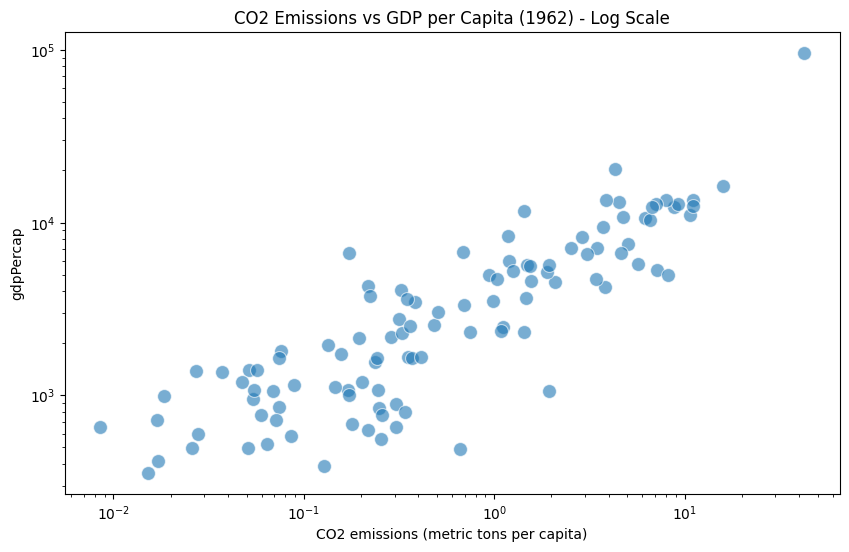

In [7]:
df_1962 = df[df['Year'] == 1962]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_1962, x='CO2 emissions (metric tons per capita)', y='gdpPercap', alpha=0.6, s=100)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('CO2 emissions (metric tons per capita)')
plt.ylabel('gdpPercap')
plt.title('CO2 Emissions vs GDP per Capita (1962) - Log Scale');

3. On the filtered data, calculate the correlation of `'CO2 emissions (metric tons per capita)'` and `gdpPercap`. What is the correlation and associated p value?

In [10]:
df_clean = df_1962[['CO2 emissions (metric tons per capita)', 'gdpPercap']].dropna()
r, p_value = stats.pearsonr(df_clean['CO2 emissions (metric tons per capita)'], df_clean['gdpPercap'])
print(f"Pearson correlation (r): {r:.4f}")
print(f"p-value: {p_value:.2e}")

Pearson correlation (r): 0.9261
p-value: 1.13e-46


4. On the unfiltered data, answer "In what year is the correlation between `'CO2 emissions (metric tons per capita)'` and `gdpPercap` the strongest?"

In [11]:
yearly_corr = df.groupby('Year')[['CO2 emissions (metric tons per capita)', 'gdpPercap']].corr().unstack()['CO2 emissions (metric tons per capita)']['gdpPercap']
best_year = yearly_corr.idxmax()
best_year  

np.int64(1967)

Filter the dataset to that year for the next step...

In [12]:
df_best_year = df[df['Year'] == best_year]
df_best_year.head()

,Unnamed: 0,Country Name,Year,"Agriculture, value added (% of GDP)",CO2 emissions (metric tons per capita),Domestic credit provided by financial sector (% of GDP),Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),"Fertility rate, total (births per woman)",GDP growth (annual %),Imports of goods and services (% of GDP),"Industry, value added (% of GDP)","Inflation, GDP deflator (annual %)","Life expectancy at birth, total (years)",Population density (people per sq. km of land area),"Services, etc., value added (% of GDP)",pop,continent,gdpPercap
1,1,Afghanistan,1967,NaN,0.123782,9.917662,NaN,NaN,6.772908,7.450,NaN,14.209827,NaN,NaN,35.389415,15.881812,NaN,11537966.0,Asia,836.197138
11,11,Albania,1967,NaN,1.363746,NaN,NaN,NaN,NaN,5.394,NaN,NaN,NaN,NaN,66.287220,71.737153,NaN,1984060.0,Europe,2760.196931
21,21,Algeria,1967,10.330666,0.632118,27.977088,NaN,NaN,23.434417,7.672,9.452963,21.631769,42.385889,1.312041,49.187512,5.606908,47.28345,12760499.0,Africa,3246.991771
31,31,American Samoa,1967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.580000,NaN,NaN,NaN,NaN
41,41,Andorra,1967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.159574,NaN,NaN,NaN,NaN


5. Using `plotly` or `bokeh`, create an interactive scatter plot comparing `'CO2 emissions (metric tons per capita)'` and `gdpPercap`, where the point size is determined by `pop` (population) and the color is determined by the `continent`.

In [15]:
fig = px.scatter(df_best_year,
                 x='gdpPercap',
                 y='CO2 emissions (metric tons per capita)',
                 size='pop',
                 size_max = 40,
                 color='continent',
                 log_x=True,
                 log_y=True,
                 hover_data=['Country Name', 'Year'],
                 title='CO2 Emissions vs GDP per Capita (Log Scale)',
                 labels={'CO2 emissions (metric tons per capita)': 'CO2 emissions (metric tons per capita)',
                         'gdpPercap': 'GDP per Capita'})
fig.update_traces(marker=dict(sizemode='area', sizemin=5))
fig.update_xaxes(tickformat="$,.0f")
fig.show()

1. What is the relationship between `continent` and `'Energy use (kg of oil equivalent per capita)'`? (Stats test needed)

In [16]:
# Prepare data for ANOVA
groups = [g.dropna() for _, g in df.groupby('continent')['Energy use (kg of oil equivalent per capita)']]
# Perform one-way ANOVA
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat}") 
print(f"p-value: {p_value_anova}")

F-statistic: 51.45915759042634
p-value: 8.527003487154367e-39


     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1   group2   meandiff p-adj    lower     upper   reject
-------------------------------------------------------------
  Africa Americas 1005.1037    0.0  466.8326 1543.3748   True
  Africa     Asia 1168.7636    0.0  628.2529 1709.2742   True
  Africa   Europe 2447.5453    0.0 1947.3838 2947.7067   True
  Africa  Oceania 3281.7976    0.0  2040.341 4523.2543   True
Americas     Asia  163.6599 0.9256  -384.416  711.7357  False
Americas   Europe 1442.4416    0.0  934.1141 1950.7691   True
Americas  Oceania  2276.694    0.0 1031.9249  3521.463   True
    Asia   Europe 1278.7817    0.0  768.0834 1789.4801   True
    Asia  Oceania 2113.0341    0.0   867.295 3358.7732   True
  Europe  Oceania  834.2524 0.3422 -394.5176 2063.0223  False
-------------------------------------------------------------


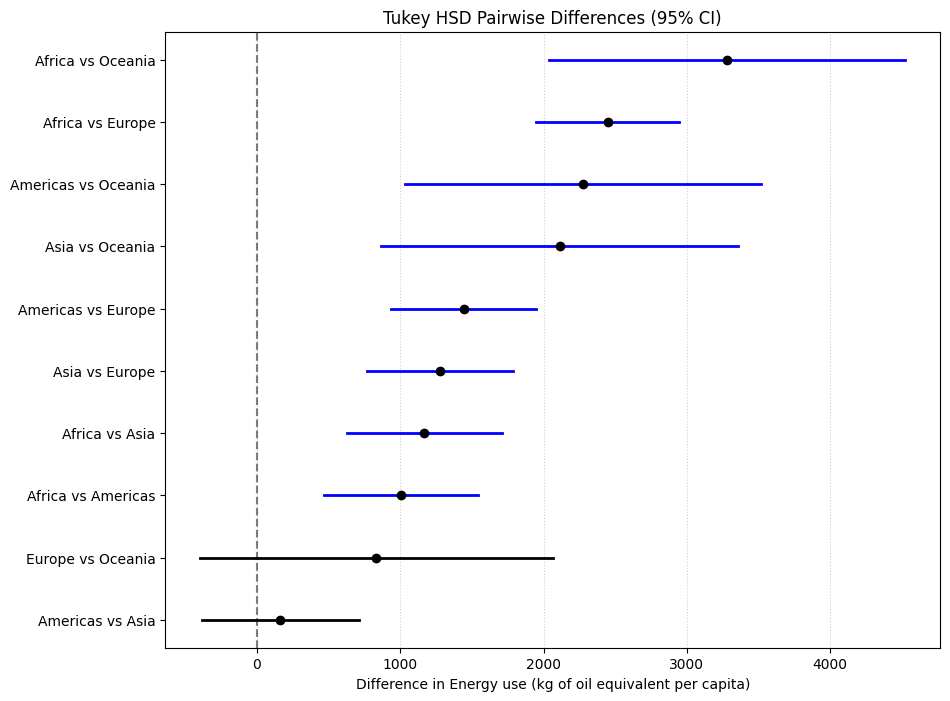

In [17]:
df_clean = df.dropna(subset=['Energy use (kg of oil equivalent per capita)', 'continent'])
tukey = pairwise_tukeyhsd(endog=df_clean['Energy use (kg of oil equivalent per capita)'], 
                          groups=df_clean['continent'], 
                          alpha=0.05)
print(tukey)
tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0]) \
             .sort_values(by='meandiff').reset_index(drop=True)
plt.figure(figsize=(10, 8))

for i, row in tukey_df.iterrows():
    color = 'blue' if row['reject'] else 'black'
    plt.plot([row['lower'], row['upper']], [i, i], color=color, linewidth=2)
    plt.plot(row['meandiff'], i, 'ko') 
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
pairs = tukey_df['group1'] + ' vs ' + tukey_df['group2']
plt.yticks(range(len(tukey_df)), pairs)
plt.xlabel('Difference in Energy use (kg of oil equivalent per capita)')
plt.title('Tukey HSD Pairwise Differences (95% CI)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

2. Is there a significant difference between Europe and Asia with respect to `'Imports of goods and services (% of GDP)'` in the years after 1990? (Stats test needed)

In [18]:
from scipy.stats import shapiro

# Filter data for Asia and Europe after 1990
df_asia_europe = df[(df['Year'] > 1990) & (df['continent'].isin(['Asia', 'Europe']))].copy()

# Separate data by continent
asia_imports = df_asia_europe[df_asia_europe['continent'] == 'Asia']['Imports of goods and services (% of GDP)'].dropna()
europe_imports = df_asia_europe[df_asia_europe['continent'] == 'Europe']['Imports of goods and services (% of GDP)'].dropna()

# Perform Shapiro-Wilk test for each continent

stat_asia, p_asia = shapiro(asia_imports)
stat_europe, p_europe = shapiro(europe_imports)

print("Shapiro-Wilk Normality Test Results:")
print(f"\nAsia:")
print(f"  Test statistic: {stat_asia:.6f}")
print(f"  p-value: {p_asia:.6e}")
print(f"  Normal: {'Yes' if p_asia > 0.05 else 'No'}")

print(f"\nEurope:")
print(f"  Test statistic: {stat_europe:.6f}")
print(f"  p-value: {p_europe:.6e}")
print(f"  Normal: {'Yes' if p_europe > 0.05 else 'No'}")

Shapiro-Wilk Normality Test Results:

Asia:
  Test statistic: 0.854897
  p-value: 2.309692e-08
  Normal: No

Europe:
  Test statistic: 0.929049
  p-value: 1.363335e-05
  Normal: No


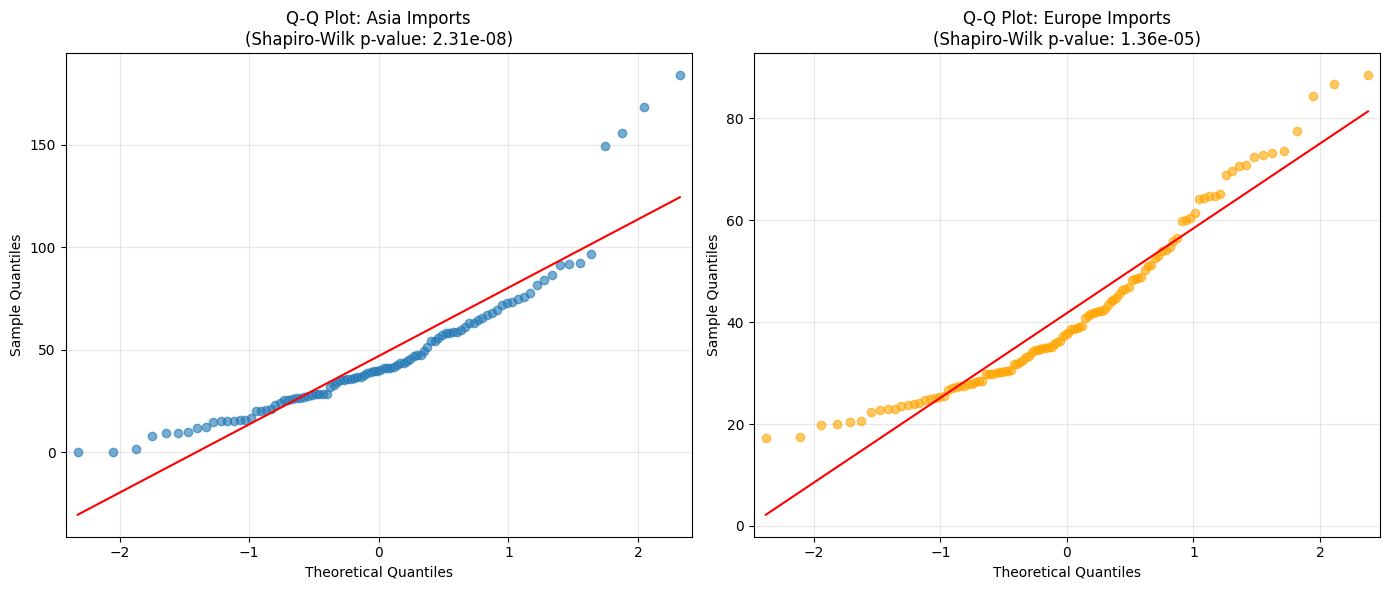

In [19]:
import statsmodels.api as sm
p_asia = stats.shapiro(asia_imports.dropna())[1]
p_europe = stats.shapiro(europe_imports.dropna())[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(asia_imports.dropna(), line='s', ax=axes[0], alpha=0.6)
axes[0].set_title(f'Q-Q Plot: Asia Imports\n(Shapiro-Wilk p-value: {p_asia:.2e})')
axes[0].grid(alpha=0.3)

sm.qqplot(europe_imports.dropna(), line='s', ax=axes[1], alpha=0.6)
axes[1].get_lines()[0].set_markerfacecolor('orange') 
axes[1].get_lines()[0].set_markeredgecolor('orange')

axes[1].set_title(f'Q-Q Plot: Europe Imports\n(Shapiro-Wilk p-value: {p_europe:.2e})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Perform Mann-Whitney U test (non-parametric alternative to t-test)
stat_mw, p_value_mw = stats.mannwhitneyu(asia_imports, europe_imports, alternative='two-sided')
print(f"Mann-Whitney U Test Results:")
print(f"Test statistic: {stat_mw:.1f}")
print(f"p-value: {p_value_mw:.4f}")
print(f"\nConclusion: {'Significant difference' if p_value_mw < 0.05 else 'No significant difference'} between Asia and Europe imports (α=0.05)")

Mann-Whitney U Test Results:
Test statistic: 5707.0
p-value: 0.7867

Conclusion: No significant difference between Asia and Europe imports (α=0.05)


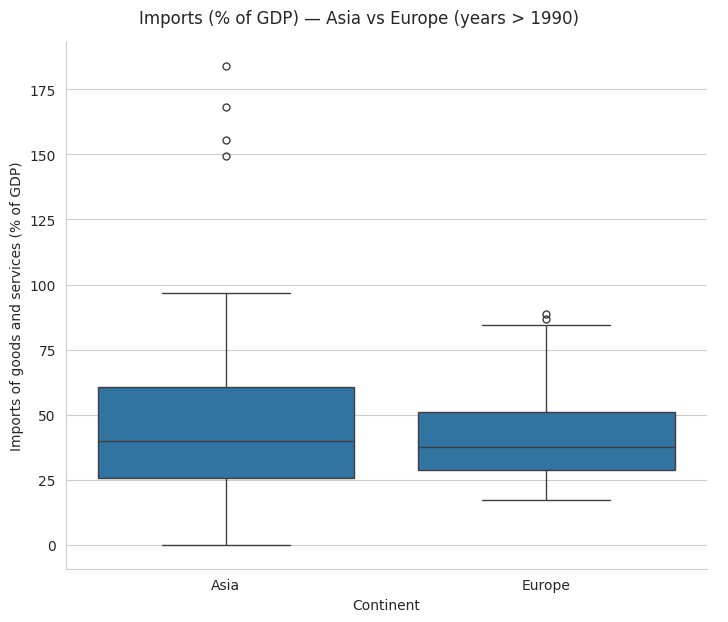

In [21]:
# Box catplot for the samples used in Shapiro-Wilk / Mann-Whitney tests
plot_df = df_asia_europe[['continent', 'Imports of goods and services (% of GDP)']].dropna()
sns.set_style('whitegrid')
g = sns.catplot(
    data=plot_df,
    x='continent',
    y='Imports of goods and services (% of GDP)',
    kind='box',
    order=['Asia', 'Europe'],
    height=6,
    aspect=1.2
)
g.set_axis_labels("Continent", "Imports of goods and services (% of GDP)")
g.fig.suptitle('Imports (% of GDP) — Asia vs Europe (years > 1990)', y=1.03)
plt.show()